# Auteurs:
### Tom Coulliaud-Maisonneuve
### Cédric Brzyski

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import math
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
!tar xzf /kaggle/input/navires-2025/ships.tgz

In [3]:
!ls /kaggle/working/ships32

coastguard     corvette  cv	    ferry      sailing	  submarine  vsmallfish
containership  cruiser	 destroyer  methanier  smallfish  tug


### Get the dimension of the image

In [4]:
from PIL import Image

img = Image.open('/kaggle/working/ships32/submarine/12.jpg')
print(img.size)
print(img.mode)

(32, 32)
RGB


# Load training images

In [5]:
train_dir = "/kaggle/working/ships32"
img_size = (64, 64)
img_batch_size = 16
print(img_size)

(64, 64)


In [6]:
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=img_batch_size,
    label_mode='int',
    shuffle=True,
    labels='inferred',
    seed=444,
    color_mode='rgb',
    verbose=True,
    validation_split=0.2,
    subset="training"
)

validation_dataset = image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=img_batch_size,
    label_mode='int',
    shuffle=True,
    labels='inferred',
    seed=444,
    color_mode='rgb',
    verbose=True,
    validation_split=0.2,
    subset="validation"
)

# Recentrage en plus de la normalisation
def preprocess_img(image, label):
    image = (tf.cast(image, tf.float32) / 255.0) - 0.5
    return image, label

n_validation_dataset = validation_dataset.map(preprocess_img)

Found 48330 files belonging to 13 classes.
Using 38664 files for training.


I0000 00:00:1747829252.241718      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 48330 files belonging to 13 classes.
Using 9666 files for validation.


In [7]:
print("Classes in the dataset:")
print(train_dataset.class_names)

Classes in the dataset:
['coastguard', 'containership', 'corvette', 'cruiser', 'cv', 'destroyer', 'ferry', 'methanier', 'sailing', 'smallfish', 'submarine', 'tug', 'vsmallfish']


## Data augmentation to have more data

In [8]:
def augment_img(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.05)
    image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.random_hue(image, max_delta=0.1)
    image = tf.cast(image, tf.float32) / 255.0 - 0.5
    return image, label

n_train_dataset = train_dataset.map(augment_img, num_parallel_calls=tf.data.AUTOTUNE)
n_train_dataset = n_train_dataset.prefetch(tf.data.AUTOTUNE)
print(len(n_train_dataset))

2417


## Image visu

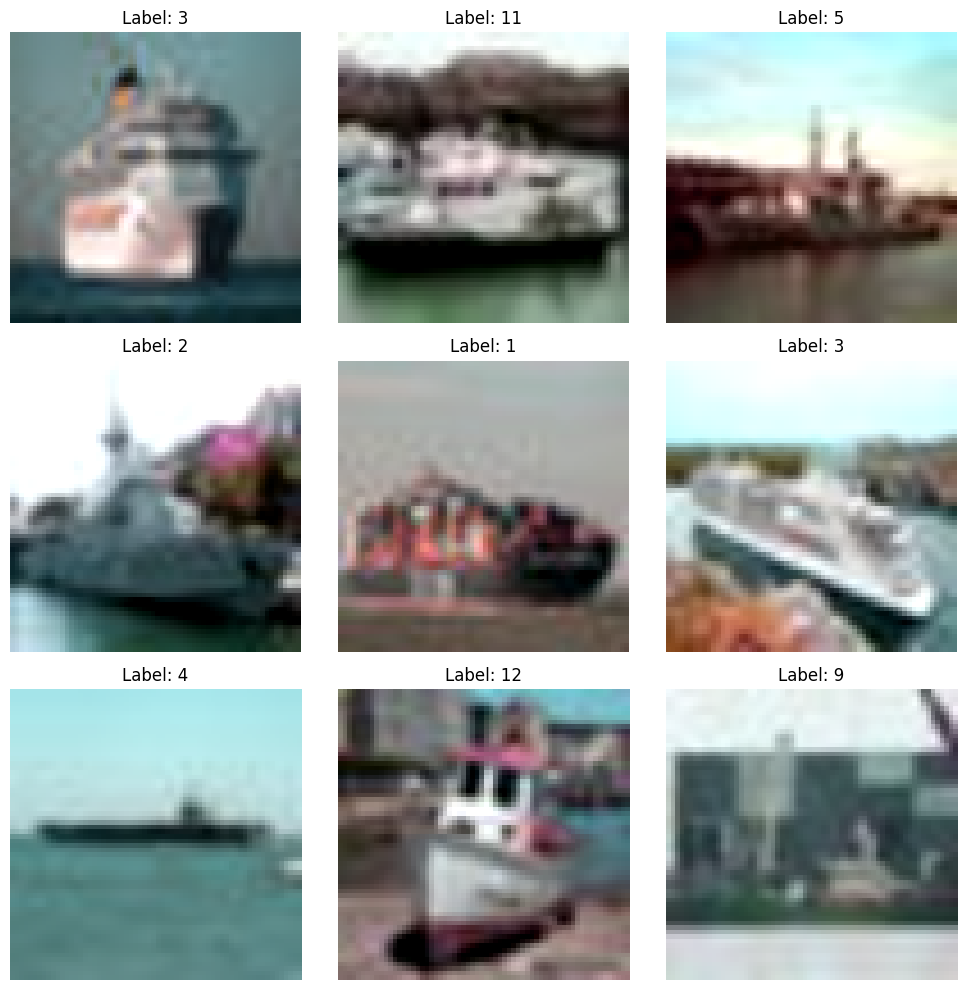

In [9]:
def show_dataset_samples(dataset, class_names=None, num_images=9):
    plt.figure(figsize=(10, 10))
    
    for images, labels in dataset.take(1):
        actual_num_images = min(num_images, images.shape[0])  # Empêche le dépassement
        for i in range(actual_num_images):
            ax = plt.subplot(3, 3, i + 1)
            img = images[i].numpy()
            label = labels[i].numpy()

            img = (img + 0.5)
            img = np.clip(img, 0, 1)

            plt.imshow(img)
            if class_names:
                plt.title(class_names[label])
            else:
                plt.title(f"Label: {label}")
            plt.axis("off")
        break
    plt.tight_layout()
    plt.show()

show_dataset_samples(n_train_dataset)

# Models

In [10]:
num_classes = len(train_dataset.class_names)
input_shape = (64, 64, 3)

## Second model : high score with 0.87174

In [11]:
from tensorflow.keras import models, layers, regularizers

def build_improved_ship_model(input_shape, num_classes):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # First Conv Block
        layers.Conv2D(64, (3, 3), padding='same', activation='relu', 
                     kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Second Conv Block
        layers.Conv2D(128, (3, 3), padding='same', activation='relu',
                     kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Third Conv Block
        layers.Conv2D(256, (3, 3), padding='same', activation='relu',
                     kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        # Fourth Conv Block (new)
        layers.Conv2D(512, (3, 3), padding='same', activation='relu',
                     kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Feature aggregation
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-5)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the model
improved_model = build_improved_ship_model(input_shape, num_classes)

improved_model.summary()
print(len(improved_model.layers))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 8, 8, 512)           │       2,359,8

 Total params: 4,858,957 (18.54 MB)

 Trainable params: 4,855,117 (18.52 MB)

 Non-trainable params: 3,840 (15.00 KB)

29


### Declaring optimization tools

In [12]:
from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam, SGD,AdamW

weights_path = "/kaggle/working/train.weights.h5"

# Callbacks
checkpoint = callbacks.ModelCheckpoint(
    weights_path,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=True
)

early_stopping = callbacks.EarlyStopping(
    monitor='val_accuracy', mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', mode="max",
    factor=0.2,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

# Optimizers
adam = lambda: Adam(learning_rate=1e-4)
adamW = lambda: AdamW(learning_rate=1e-4)
sgd = lambda: SGD(learning_rate=0.001, momentum=0.9)

### Declaring train function for multi-step trainings

In [13]:
def train_model(model, training, validation, optimizers=[], callbacks_list=[], epochs_list=[]):
    if not (len(optimizers) == len(callbacks_list) == len(epochs_list)):
        print(f"[ERROR] Mismatch in training configuration lengths:")
        print(f" - optimizers: {len(optimizers)}")
        print(f" - callbacks:  {len(callbacks_list)}")
        print(f" - epochs:     {len(epochs_list)}")
        return None

    history_list = []

    for i in range(len(optimizers)):
        print("=" * 50)
        print(f"Training Stage {i + 1}/{len(optimizers)}")

        # Instantiate optimizer and log learning rate if applicable
        optimizer = optimizers[i]()
        lr = getattr(optimizer, 'learning_rate', None)
        if lr is not None:
            print(f"Optimizer: {type(optimizer).__name__} | LR: {lr.numpy() if hasattr(lr, 'numpy') else lr}")
        else:
            print(f"Optimizer: {type(optimizer).__name__}")

        epochs = epochs_list[i]
        callbacks = callbacks_list[i]

        # Compile model
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train model
        history = model.fit(
            training,
            validation_data=validation,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        print(f"Completed Stage {i + 1} with {epochs} epochs.\n")
        history_list.append(history)

    print("All training stages completed.")
    return history_list

In [14]:
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(444)

model = build_improved_ship_model(input_shape, num_classes)

In [15]:
print("Nombre de couches : ", len(model.layers))

Nombre de couches :  29


In [16]:
from tensorflow.keras.models import load_model

weights_path_trained = '/kaggle/input/best_model_from_pc/keras/default/1/goated_model3.weights.h5'
retrain = False

# If the model was trained and we want to continue the training
if (retrain):
    model.load_weights(weights_path_trained)

In [17]:
# Training models
history = train_model(
    model,
    training=n_train_dataset,
    validation=n_validation_dataset,
    optimizers=[
        lambda: Adam(learning_rate=1e-4), # Stage 1
        lambda: Adam(learning_rate=1e-5), # Stage 2
        lambda: Adam(learning_rate=1e-6)  # Stage 3
    ],
    callbacks_list=[
        [checkpoint, reduce_lr],  # Stage 1
        [checkpoint, reduce_lr],  # Stage 2
        [checkpoint, reduce_lr]   # Stage 3
    ],
    epochs_list=[44, 32, 12]
)

Training Stage 1/3
Optimizer: Adam | LR: 9.999999747378752e-05
Epoch 1/44


I0000 00:00:1747829299.000284     102 service.cc:148] XLA service 0x7fe628023880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747829299.002300     102 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1747829300.020763     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


   8/2417 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.0384 - loss: 3.9158      

I0000 00:00:1747829308.462131     102 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2417/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1445 - loss: 3.2974
Epoch 1: val_accuracy improved from -inf to 0.29288, saving model to /kaggle/working/train.weights.h5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 72s 22ms/step - accuracy: 0.1445 - loss: 3.2972 - val_accuracy: 0.2929 - val_loss: 2.5093 - learning_rate: 1.0000e-04
Epoch 2/44
2416/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2601 - loss: 2.5104
Epoch 2: val_accuracy improved from 0.29288 to 0.41041, saving model to /kaggle/working/train.weights.h5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.2601 - loss: 2.5103 - val_accuracy: 0.4104 - val_loss: 1.8640 - learning_rate: 1.0000e-04
Epoch 3/44
2414/2417 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3621 - loss: 2.0322
Epoch 3: val_accuracy improved from 0.41041 to 0.47993, saving model to /kaggle/working/train.weights.h5
2417/2417 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.3621 - loss: 2.0320 - val_accuracy: 0.4799 - val_loss: 1.5901 - learning_ra

FileNotFoundError: [Errno 2] Unable to synchronously create file (unable to open file: name = '/kaggle/input/best_model_from_pc/keras/default/1/goated_model3.weights.h5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 242)

In [18]:
# Save the model
weights_path = "/kaggle/working/train.weights.h5"
model.save_weights(weights_path)

#### Try to improve the model with even more training without callbacks to see

In [19]:
print(history)

[<keras.src.callbacks.history.History object at 0x7fe6ec24b050>, <keras.src.callbacks.history.History object at 0x7fe612d9d610>, <keras.src.callbacks.history.History object at 0x7fe631f29b50>]


### Debug tool to see regularization usefulness

In [20]:
for layer in model.layers:
    # Si la couche a des poids (par exemple, Dense ou Conv2D)
    if len(layer.get_weights()) > 0:
        weights = layer.get_weights()[0]  # Les poids
        print(f"Couches : {layer.name}")
        #print(weights) 
        print(f"Max weight: {np.max(weights)} | Min weight: {np.min(weights)} | Mean weight: {np.mean(weights)} | Diff: {np.max(weights) - np.min(weights)}\n")

Couches : conv2d_8
Max weight: 0.15196733176708221 | Min weight: -0.15394745767116547 | Mean weight: -0.00041929169674403965 | Diff: 0.3059147894382477

Couches : batch_normalization_8
Max weight: 1.4085975885391235 | Min weight: 0.8497222065925598 | Mean weight: 0.9896491169929504 | Diff: 0.5588753819465637

Couches : conv2d_9
Max weight: 0.2782112658023834 | Min weight: -0.2788272202014923 | Mean weight: 9.274575859308243e-06 | Diff: 0.5570384860038757

Couches : batch_normalization_9
Max weight: 1.0750083923339844 | Min weight: 0.8980247974395752 | Mean weight: 0.9948447942733765 | Diff: 0.17698359489440918

Couches : conv2d_10
Max weight: 0.2133348286151886 | Min weight: -0.26825129985809326 | Mean weight: -0.003574325703084469 | Diff: 0.48158612847328186

Couches : batch_normalization_10
Max weight: 1.0877281427383423 | Min weight: 0.8651776313781738 | Mean weight: 0.979986846446991 | Diff: 0.22255051136016846

Couches : conv2d_11
Max weight: 0.16461077332496643 | Min weight: -0.1

### Training display

In [21]:
def plot_training_history(history_list):
    plt.figure(figsize=(12, 4))
    
    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    for i, history in enumerate(history_list):
        plt.plot(history.history['accuracy'], label=f'Step {i+1} Train Acc')
        plt.plot(history.history['val_accuracy'], label=f'Step {i+1} Val Acc')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    for i, history in enumerate(history_list):
        plt.plot(history.history['loss'], label=f'Step {i+1} Train Loss')
        plt.plot(history.history['val_loss'], label=f'Step {i+1} Val Loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Confusion matrix display

In [22]:
def plot_confusion_matrix(model, dataset):
    # Get all labels and predictions
    y_true = []
    y_pred = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(predictions, axis=1))
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax)
    plt.title('Confusion Matrix')
    plt.show()

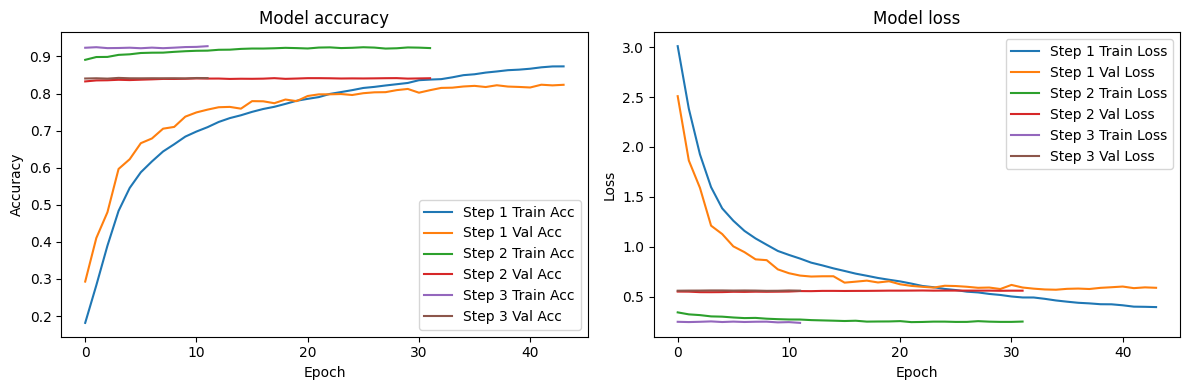

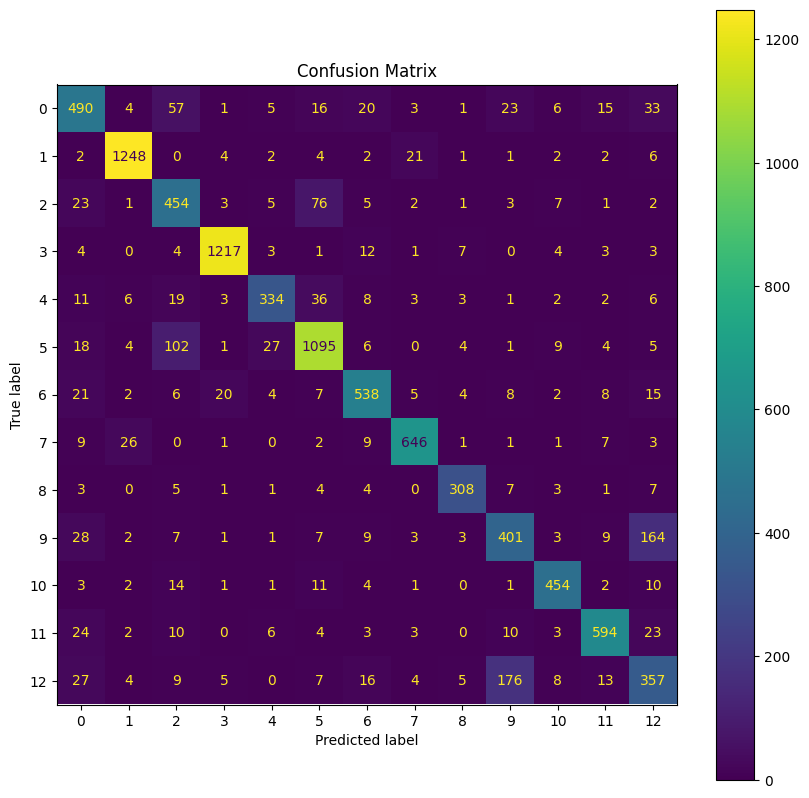

In [23]:
if history is not None:
    # Plot the curve
    plot_training_history(history)
    
    # Plot confusion matrix for validation data
    plot_confusion_matrix(model, n_validation_dataset)

# Loading final data

In [24]:
X_test = np.load('/kaggle/input/navires-2025/ships_competition.npz', allow_pickle=True)['X']
tta_steps = 46
target_size = (64, 64)
total_images = len(X_test)
print(total_images)

2000


# Results to submit using TTA

For the submission, we decided to use the TTA technique that allows us to have better results using more data for each image and thus the reliability of the results is better

In [33]:
def predict_with_tta_rgb(
    model,
    X_test,
    n_augmentations=5,
    output_csv="reco_nav2.csv",
    batch_size=32
):
    # Normalize once globally
    X_test = X_test.astype(np.float32) / 255.0 - 0.5  
    X_test_tensor = tf.convert_to_tensor(X_test)

    def tta_augment_single(image):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, max_delta=0.05)
        image = tf.image.random_contrast(image, lower=0.6, upper=1.4)
        image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
        image = tf.image.random_hue(image, max_delta=0.1)
        return tf.clip_by_value(image, -0.5, 0.5)  # Keep values in normalized range

    def tta_augment_batch(images):
        return tf.map_fn(tta_augment_single, images)

    all_preds = []

    for i in range(n_augmentations):
        print(f"TTA round {i + 1}/{n_augmentations}")
        augmented = tta_augment_batch(X_test_tensor)
        preds = model.predict(augmented, batch_size=batch_size, verbose=0)
        all_preds.append(preds)

    # Also include unaugmented prediction
    print("TTA round original")
    original_preds = model.predict(X_test_tensor, batch_size=batch_size, verbose=0)
    all_preds.append(original_preds)

    final_preds = np.mean(np.stack(all_preds), axis=0)
    predicted_classes = np.argmax(final_preds, axis=1)

    # Save as DataFrame
    df = pd.DataFrame({"Category": predicted_classes})
    df.to_csv(output_csv, index_label="Id")

    return predicted_classes

In [ ]:
preds = predict_with_tta_rgb(model, X_test, n_augmentations=42, output_csv="reco_nav3.csv")

TTA round 1/42
TTA round 2/42
TTA round 3/42
TTA round 4/42
TTA round 5/42
TTA round 6/42
TTA round 7/42
TTA round 8/42
TTA round 9/42
TTA round 10/42
TTA round 11/42
TTA round 12/42
TTA round 13/42
TTA round 14/42
TTA round 15/42
TTA round 16/42
TTA round 17/42
TTA round 18/42
TTA round 19/42
TTA round 20/42
TTA round 21/42
TTA round 22/42
TTA round 23/42
TTA round 24/42
TTA round 25/42
TTA round 26/42
TTA round 27/42
TTA round 28/42
TTA round 29/42
TTA round 30/42
TTA round 31/42
TTA round 32/42
TTA round 33/42
TTA round 34/42
TTA round 35/42
TTA round 36/42
TTA round 37/42
TTA round 38/42


In [27]:
!ls /kaggle/working/

reco_nav3.csv  ships32	train.weights.h5


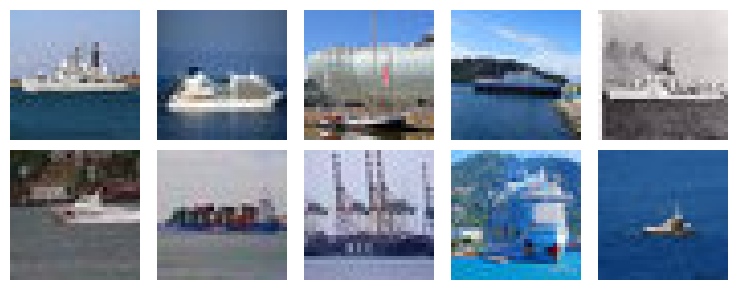

In [29]:
# printing test images for debug
def show_images(images, cols=5, scale=1.5):
    nb_img = images.shape[0]
    rows = (nb_img + cols - 1) // cols  # ceiling division

    fig, axes = plt.subplots(rows, cols, figsize=(cols * scale, rows * scale))

    # If there's only one row or column, make sure axes is always 2D
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i < nb_img:
            ax.imshow(images[i])
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_images(X_test[:10])

### Submission with TTA

In [20]:
df = pd.DataFrame({"Category": test_predictions})
df.to_csv("reco_nav.csv", index_label="Id")

### Submission without TTA

In [31]:
res = model.predict(X_test).argmax(axis=1)
df = pd.DataFrame({"Category":res})
df.to_csv("reco_nav.csv", index_label="Id")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [32]:
!head -n 30 reco_nav.csv

Id,Category
0,8
1,9
2,9
3,7
4,9
5,9
6,9
7,9
8,9
9,8
10,9
11,9
12,9
13,9
14,9
15,9
16,9
17,3
18,9
19,0
20,9
21,9
22,9
23,9
24,9
25,9
26,9
27,9
28,9


In [38]:
import os
os.chdir(r'/kaggle/working')
from IPython.display import FileLink
FileLink(r'reco_nav2.csv')

/kaggle/working/reco_nav2.csv